In [1]:
#数据处理模块，以及依赖库导入
%run data_process.ipynb
import tensorflow as tf
import time
from net.base_cnn import *
from net.triplet import *
from tensorflow.keras import optimizers


from sklearn import datasets       #导入数据模块
from sklearn.model_selection import train_test_split     #导入切分训练集、测试集模块
from sklearn.neighbors import KNeighborsClassifier

from sklearn.manifold import TSNE
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np
import random

# 该部分代码主要用于对第一阶段与第二阶段进行原始音频测试实验

In [2]:
# #数据预处理内容，仅需处理一次

# #对原音频进行长度整合切分
# clip_audio()

# #训练集降噪，测试集降噪，结果集降噪
# reduce_noise()
# reduce_noise_for_test()

In [3]:
#按照顺序，不打乱的提取去一定格式的训练和验证数据
#获取三类训练数据
#获取三类验证数据
#True代表全切，False代表剔除

train_datas=get_datas_test('train',All=False)
val_datas=get_datas_test('test',All=False)



79
108
93
geting data: train AD
(3999, 32000) train
geting data: train HC
(5029, 32000) train
geting data: train MCI
(4327, 32000) train
35
45
39
geting data: test AD


C:\Users\dell\AppData\Local\Temp\ipykernel_3092\940714867.py:110: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return np.array(datas)#直接用datas.shape一定是(3,)因为它不是矩阵，每一行的长度不同。


(1846, 32000) test
geting data: test HC
(2231, 32000) test
geting data: test MCI
(1993, 32000) test


In [4]:
print(train_datas[0].shape,train_datas[1].shape,train_datas[2].shape)
#分别生成用于模型1与模型2的训练和验证数据
train_d_one=[[],[]]
val_d_one=[[],[]]

train_d_two=[[],[]]
val_d_two=[[],[]]

print(train_datas[0].shape)

#train与val datas中  0为AD 1为HC 2为MCI

#train_d_one中，0为AD 1为HC与MCI
train_d_one[0]=train_datas[0]
np.random.shuffle(train_d_one[0])
#----------------------------------------
# np.random.shuffle(train_datas[1])
# np.random.shuffle(train_datas[2])


# temp_one=np.concatenate((train_datas[1][:train_d_one[0].shape[0]//2],train_datas[2][:train_d_one[0].shape[0]//2]),axis=0)
# np.random.shuffle(temp_one)
# train_d_one[1]=temp_one
#----------------------------------------

np.random.shuffle(train_datas[1])
np.random.shuffle(train_datas[2])

train_d_one[1]=(np.concatenate((train_datas[1][:len(train_datas[0])//2],train_datas[2][:len(train_datas[0])//2]),axis=0))
np.random.shuffle(train_d_one[1])





#val_d_one中，0为AD 1为HC与MCI
val_d_one[0]=val_datas[0]
np.random.shuffle(val_d_one[0])
#---------------------------------------------
# np.random.shuffle(val_datas[1])
# np.random.shuffle(val_datas[2])

# temp_two=np.concatenate((val_datas[1][:val_d_one[0].shape[0]//2],val_datas[2][:val_d_one[0].shape[0]//2]),axis=0)
# np.random.shuffle(temp_two)

# val_d_one[1]=temp_two
#----------------------------------------

np.random.shuffle(val_datas[1])
np.random.shuffle(val_datas[2])

val_d_one[1]=(np.concatenate((val_datas[1][:len(val_datas[0])//2],val_datas[2][:len(val_datas[0])//2]),axis=0))
np.random.shuffle(val_d_one[1])



print("this is the train datas for one")
print("AD:",train_d_one[0].shape,' ',"HC,MCI:",train_d_one[1].shape)
print("this is the val datas for one")
print("AD:",val_d_one[0].shape,' ',"HC,MCI:",val_d_one[1].shape)
print("=============================================================================")


#train_d_two中，0为HC 1为MCI
train_d_two[0]=train_datas[1]
train_d_two[1]=train_datas[2]

#val_d_two中，0为HC 1为MCI
val_d_two[0]=val_datas[1]
val_d_two[1]=val_datas[2]

print("this is the train datas for two")
print("HC:",train_d_two[0].shape,' ',"MCI:",train_d_two[1].shape)
print("this is the val datas for two")
print("HC:",val_d_two[0].shape,' ',"MCI:",val_d_two[1].shape)
print("=============================================================================")

train_d_one=np.array(train_d_one)
val_d_one=np.array(val_d_one)

train_d_two=np.array(train_d_two)
val_d_two=np.array(val_d_two)


(3999, 32000) (5029, 32000) (4327, 32000)
(3999, 32000)
this is the train datas for one
AD: (3999, 32000)   HC,MCI: (3998, 32000)
this is the val datas for one
AD: (1846, 32000)   HC,MCI: (1846, 32000)
this is the train datas for two
HC: (5029, 32000)   MCI: (4327, 32000)
this is the val datas for two
HC: (2231, 32000)   MCI: (1993, 32000)


C:\Users\dell\AppData\Local\Temp\ipykernel_3092\1562620213.py:78: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  train_d_one=np.array(train_d_one)
C:\Users\dell\AppData\Local\Temp\ipykernel_3092\1562620213.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  train_d_two=np.array(train_d_two)
C:\Users\dell\AppData\Local\Temp\ipykernel_3092\1562620213.py:82: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do

In [5]:
#当前已经获取到训练集以及验证集数据。

#train_d_one=[[],[]]
#val_d_one=[[],[]]

#train_d_two=[[],[]]
#val_d_two=[[],[]]

# def make_triplet_test(datas,BATCH_SIZE):
#     triplet_datas=[]
#     for i  in range(2):#因一共两类
#         Len=datas[i].shape[0]
#         for j in range(Len):#遍历当前类
#             for k in range(1):#随机样本选取个数
#                 #选取anchor
#                 anchor=datas[i][j]
            
#                 #选择positive_1
#                 positive_1 = datas[i][random.randrange(0, Len)]
            
            
#                 #选择negative_1
#                 inc = random.randrange(1, 2)#选取一个1到2（不包含2）的随机整数
#                 dn1 = (i + inc) % 2#取得新的类别的下标
#                 Len_dn1=datas[dn1].shape[0]
#                 negative_1 = datas[dn1][random.randrange(0,Len_dn1)]#选从随机取得的类中，随机选一个样本
            
            
#                 triplet_datas+=[[anchor,positive_1,negative_1]]
            
#     #数据对已经创建完毕,将其转换为numpy，方便重新排序。
#     triplet_datas=np.array(triplet_datas)
#     '''
#     np.random.shuffle(triplet_datas)
#     triplet_datas=triplet_datas[:(int)(triplet_datas.shape[0]*(1/2))]
#     '''
#     print(triplet_datas.shape[0])
    
#     triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,32000,1) #将音频格式转为适合卷积的标准形式，增加一个维度，表示一个通道。
    
#     labels = np.empty((triplet_datas.shape[0],))
    
#     datas = tf.data.Dataset.from_tensor_slices((triplet_datas, labels))
    
#     datas=datas.shuffle(labels.shape[0]).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
   
   
#     return datas




# def read_from_paths(image_path_list, mask_path_list):
# 	# image_path_list: 图片路径列表
# 	# mask_path_list: 标签路径列表
# 	# 返回4-D图片numpy array和4-D标签numpy array
#     images = []
#     masks = []
#     for img_path, mask_path in zip(image_path_list, mask_path_list):
#         image = cv2.imread(img_path).astype('float32')
#         mask = cv2.imread(mask_path, 0).astype('int64')
#         mask = np.expand_dims(mask, -1)
#         images.append(image / 255.0)
#         masks.append(mask // 255)
#     images_array = np.array(images)
#     masks_array = np.array(masks)
#     return images_array, masks_array


# generator
# def gen_image_mask(all_image_paths, all_mask_paths, batch_size, reshuffle_each_iteration=False):
# 	# all_image_paths: 所有图片的路径列表
# 	# all_mask_paths: 所有标签的路径列表
# 	# batch_size: 批大小
# 	# reshuffle_each_iteration: 每个epoch结束后是否打乱数据
#     i = 0
#     while True:
#         images_array, masks_array = read_from_paths(
#             all_image_paths[i*batch_size:(i+1)*batch_size], all_mask_paths[i*batch_size:(i+1)*batch_size])
#         yield images_array, masks_array
#         i = (i+1) % (len(all_image_paths) // batch_size)
#         if reshuffle_each_iteration:
#             if i == 0:
#                 paths = list(zip(all_image_paths, all_mask_paths))
#                 random.shuffle(paths)
#                 all_image_paths, all_mask_paths = zip(*paths)


# all_image_paths = 所有图片路径列表
# all_mask_paths = 所有标签路径列表
# model.fit_generator(generator=gen_image_mask(all_train_image_paths, all_train_mask_paths, 4, True),
# 					steps_per_epoch=len(all_train_image_paths) // 4,
# 					validation_data=gen_image_mask(all_val_image_paths, all_val_mask_paths, 2, False),
# 					validation_steps=len(all_val_image_paths) // 2,
# 					其它参数)


In [6]:
#构造数据生成器
#generator
#需要产生格式为(batch_size,3,32000,1) 标签格式为(batch_size,)


#如何计算一个周期能生成多少批数据？
#((datas[0].shape[0]+datas[1].shape[0])*times)//batch_size


def triplet_generator(datas, batch_size, times=1,reshuffle_each_iteration=False):
# all_image_paths: 所有图片的路径列表
# all_mask_paths: 所有标签的路径列表
# batch_size: 批大小
# reshuffle_each_iteration: 每个epoch结束后是否打乱数据
    i = 0
    counts=0
    triplet_datas=[]
    while True:    
        for i  in range(2):#因一共两类,用于anchor类别的互换
            Len=datas[i].shape[0]
            for j in range(Len):#遍历当前类
                for k in range(times):#随机样本选取个数
                    #选取anchor
                    anchor=datas[i][j]

                    #选择positive_1
                    positive_1 = datas[i][random.randrange(0, Len)]


                    #选择negative_1
                    inc = random.randrange(1, 2)#选取一个1到2（不包含2）的随机整数
                    dn1 = (i + inc) % 2#取得新的类别的下标
                    Len_dn1=datas[dn1].shape[0]
                    negative_1 = datas[dn1][random.randrange(0,Len_dn1)]#选从随机取得的类中，随机选一个样本
                    triplet_datas+=[[anchor,positive_1,negative_1]]
                    counts+=1
                    if counts==batch_size:
                        triplet_datas=np.array(triplet_datas)
                        triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,32000,1)
                        labels = np.empty((triplet_datas.shape[0],))
                        yield triplet_datas, labels
                        triplet_datas=[]
                        counts=0
                        

    
#一周期生成,datas[0].shape[0]+datas[1].shape[0] 个三元组，对应批数为 (datas[0].shape[0]+datas[1].shape[0])//batch_size
#去相关样本生成器

def triplet_generator_v2(datas, batch_size ,reshuffle_each_iteration=True):
# batch_size: 批大小
# reshuffle_each_iteration: 每个epoch结束后是否打乱数据
    
    #批计数器
    counts=0
    
    #批Triplet组
    triplet_datas=[]
    
    #类长
    len_0=datas[0].shape[0]
    len_1=datas[1].shape[0]
    
    
    #不同类别下标，与当前下标
    index_0=-1
    index_1=-1
    curindex=0
    
    while True:        
        classnum=random.randint(0,1)#随机挑选类别
        
        #确定当前index
        if classnum==0:
            index_0+=1
            curindex=index_0
        else:
            index_1+=1
            curindex=index_1
            
        #不满足条件时，更换类别
        if classnum==0 and index_0>=len_0:
            classnum=1
            index_1+=1
            curindex=index_1
            
        if classnum==1 and index_1>=len_1:
            classnum=0
            index_0+=1
            curindex=index_0
        
        #一周期后打乱数据。
        if index_0>=len_0 and index_1>=len_1:
            index_0=-1
            index_1=-1
            if reshuffle_each_iteration:
                np.random.shuffle(datas[0])
                np.random.shuffle(datas[1])
            continue
            
            
        anchor=datas[classnum][curindex]
            
        #选择positive
        positive_1 = datas[classnum][random.randrange(0,datas[classnum].shape[0])]
            
        #选择negative
        dn1 = (classnum + 1) % 2#取得新的类别的下标            
        negative_1 = datas[dn1][random.randrange(0,datas[dn1].shape[0])]#选从随机取得的类中，随机选一个样本
            
        triplet_datas+=[[anchor,positive_1,negative_1]]
        counts+=1
        if counts==batch_size:
            triplet_datas=np.array(triplet_datas)
            triplet_datas=triplet_datas.reshape(triplet_datas.shape[0],3,32000,1)
            labels = np.empty((triplet_datas.shape[0],))
            yield triplet_datas, labels
            triplet_datas=[]
            counts=0

# #第一阶段

# ----CNN——LSTM


In [ ]:
#Bc_one=Base_cnn([96000,1])
Bc_one=CNN_LSTM([32000,1])
#print(Bc_one.summary())

In [7]:
print(Bc_one.summary())

NameError: name 'Bc_one' is not defined

In [7]:
#构建triplet model one
model_one=triplet_net([3,32000,1],Bc_one)

#编译并训练模型，选择适当模型保存
Lr=1e-6
model_one.compile(      
    optimizer = optimizers.RMSprop(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(15):
    model_one.fit_generator(generator=triplet_generator(train_d_one, 6, 3,reshuffle_each_iteration=False),
    steps_per_epoch=((train_d_one[0].shape[0]+train_d_one[1].shape[0])*3)//6,
    validation_data=triplet_generator(val_d_one, 6, 3,reshuffle_each_iteration=False),
    validation_steps=((val_d_one[0].shape[0]+val_d_one[1].shape[0])*3)//6)
   

NameError: name 'Bc_one' is not defined

# CNN

In [10]:
Bc_one=Base_cnn([32000,1])

In [11]:
print(Bc_one.summary())

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 32000, 1)]        0         
_________________________________________________________________
conv1d (Conv1D)              (None, 32000, 16)         64        
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 16000, 16)         0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 16000, 32)         1568      
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 8000, 32)          0         
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 8000, 64)          6208      
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 4000, 64)          0     

In [12]:
#-----当前取得最好效果 loss==1.43 lr=1e-6 精度68
#新版generator

#构建triplet model one
model_one=triplet_net([3,32000,1],Bc_one)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_one.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)


for i in range(200):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 6),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//6,
    validation_data=triplet_generator_v2(val_d_one, 6),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//6)
    Bc_one.save('save_model/model_one/'+str(i))

(None, 32000, 1)


D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 53s 33ms/step - loss: 3.0000 - val_loss: 3.0000
INFO:tensorflow:Assets written to: save_model/model_one/0\assets
   5/1332 [..............................] - ETA: 36s - loss: 3.0000

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 51s 38ms/step - loss: 3.0000 - val_loss: 2.9999
INFO:tensorflow:Assets written to: save_model/model_one/1\assets
   5/1332 [..............................] - ETA: 42s - loss: 2.9997

...

1332/1332 [==============================] - 52s 39ms/step - loss: 1.6261 - val_loss: 2.6262
INFO:tensorflow:Assets written to: save_model/model_one/32\assets
   3/1332 [..............................] - ETA: 56s - loss: 1.9776

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 55s 41ms/step - loss: 1.5662 - val_loss: 2.5809
INFO:tensorflow:Assets written to: save_model/model_one/33\assets
   3/1332 [..............................] - ETA: 1:14 - loss: 1.2573

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 50s 38ms/step - loss: 1.5589 - val_loss: 2.5763
INFO:tensorflow:Assets written to: save_model/model_one/34\assets


In [14]:
#从第8个开始
for i in range(35):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 6),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//6,
    validation_data=triplet_generator_v2(val_d_one, 6),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//6)
    Bc_one.save('save_model/model_one/'+str(i))

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 45s 33ms/step - loss: 1.5236 - val_loss: 2.5002
INFO:tensorflow:Assets written to: save_model/model_one/0\assets
   5/1332 [..............................] - ETA: 37s - loss: 2.0865

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 44s 33ms/step - loss: 1.4998 - val_loss: 2.5405
INFO:tensorflow:Assets written to: save_model/model_one/1\assets
   5/1332 [..............................] - ETA: 39s - loss: 1.4670

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


...

1332/1332 [==============================] - 45s 34ms/step - loss: 1.0541 - val_loss: 2.5376
INFO:tensorflow:Assets written to: save_model/model_one/32\assets
   5/1332 [..............................] - ETA: 40s - loss: 0.5303

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 45s 34ms/step - loss: 1.0661 - val_loss: 2.4634
INFO:tensorflow:Assets written to: save_model/model_one/33\assets
   3/1332 [..............................] - ETA: 1:00 - loss: 0.5822

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1332/1332 [==============================] - 45s 34ms/step - loss: 1.0518 - val_loss: 2.5032
INFO:tensorflow:Assets written to: save_model/model_one/34\assets


# 基于信道间注意力的1D多卷集融合

In [7]:
Bc_one=comb_cnn([32000,1])
print(Bc_one.summary())

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_4 (InputLayer)            [(None, 32000, 1)]   0                                            
__________________________________________________________________________________________________
model (Functional)              (None, 32)           9202341     input_4[0][0]                    
__________________________________________________________________________________________________
model_1 (Functional)            (None, 32)           3211173     input_4[0][0]                    
__________________________________________________________________________________________________
model_2 (Functional)            (None, 32)           1994213     input_4[0][0]                    
____________________________________________________________________________________________

In [8]:
#-----当前取得最好效果 loss==1.43 lr=1e-6 精度68
#新版generator

#构建triplet model one
model_one=triplet_net([3,32000,1],Bc_one)

#编译并训练模型，选择适当模型保存
Lr=2*1e-6
model_one.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

#从第8个开始
for i in range(200):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 6),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//6,
    validation_data=triplet_generator_v2(val_d_one, 6),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//6)
    if i>=30:
        Bc_one.save('save_model/model_one/'+str(i))

(None, 32000, 1)


D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


 570/1332 [===========>..................] - ETA: 2:17 - loss: 1.2465

KeyboardInterrupt: 

# 1DCNN+attention

In [ ]:
Bc_one=comb_cnn([32000,1])
print(Bc_one.summary())

In [ ]:
#-----当前取得最好效果 loss==1.43 lr=1e-6 精度68
#新版generator

#构建triplet model one
model_one=triplet_net([3,32000,1],Bc_one)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_one.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

#从第8个开始
for i in range(200):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 6),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//6,
    validation_data=triplet_generator_v2(val_d_one, 6),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//6)
    Bc_one.save('save_model/model_one/'+str(i))

In [ ]:
for i in range(30):
    model_one.fit_generator(generator=triplet_generator_v2(train_d_one, 6),
    steps_per_epoch=(train_d_one[0].shape[0]+train_d_one[1].shape[0])//6,
    validation_data=triplet_generator_v2(val_d_one, 6),
    validation_steps=(val_d_one[0].shape[0]+val_d_one[1].shape[0])//6)
    Bc_one.save('save_model/model_one/'+str(i+30))

# ---测试第二阶段--------------

# 1D CNN

In [53]:
Bc_two=Base_cnn([32000,1])
#构建triplet model one
model_two=triplet_net([3,32000,1],Bc_two)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_two.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(100):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 6),
    steps_per_epoch=((train_d_two[0].shape[0]+train_d_two[1].shape[0])*3)//6,
    validation_data=triplet_generator_v2(val_d_two, 6),
    validation_steps=((val_d_two[0].shape[0]+val_d_two[1].shape[0])*3)//6)
    Bc_two.save('save_model/model_two/'+str(i))

(None, 32000, 1)


D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


4678/4678 [==============================] - 155s 33ms/step - loss: 2.9878 - val_loss: 2.9632
INFO:tensorflow:Assets written to: save_model/model_two/0\assets
   3/4678 [..............................] - ETA: 4:21 - loss: 2.8786

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


4678/4678 [==============================] - 156s 33ms/step - loss: 2.9778 - val_loss: 2.9625
INFO:tensorflow:Assets written to: save_model/model_two/1\assets
   5/4678 [..............................] - ETA: 2:17 - loss: 3.0774

...

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


4678/4678 [==============================] - 160s 34ms/step - loss: 0.4984 - val_loss: 2.5587
INFO:tensorflow:Assets written to: save_model/model_two/55\assets
   5/4678 [..............................] - ETA: 2:15 - loss: 0.0837

D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


3141/4678 [===================>..........] - ETA: 45s - loss: 0.4688

KeyboardInterrupt: 

# 多卷集融合

In [7]:
Bc_two=comb_cnn([32000,1])
#构建triplet model one
model_two=triplet_net([3,32000,1],Bc_two)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_two.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(100):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 6),
    steps_per_epoch=((train_d_two[0].shape[0]+train_d_two[1].shape[0])*3)//6,
    validation_data=triplet_generator_v2(val_d_two, 6),
    validation_steps=((val_d_two[0].shape[0]+val_d_two[1].shape[0])*3)//6)
    Bc_two.save('save_model/model_two/'+str(i))

(None, 32000, 1)


D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


5190/5190 [==============================] - 1158s 221ms/step - loss: 2.9753 - val_loss: 2.9588


D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


INFO:tensorflow:Assets written to: save_model/model_two/0\assets


...

D:\anaconda\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


INFO:tensorflow:Assets written to: save_model/model_two/5\assets


D:\anaconda\lib\site-packages\tensorflow\python\keras\engine\training.py:1940: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


1200/5190 [=====>........................] - ETA: 11:50 - loss: 1.2365

KeyboardInterrupt: 

# 1d CNN+attention

In [ ]:
Bc_two=Base_cnn_3([32000,1])
#构建triplet model one
model_two=triplet_net([3,32000,1],Bc_two)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_two.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(100):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 6),
    steps_per_epoch=((train_d_two[0].shape[0]+train_d_two[1].shape[0])*3)//6,
    validation_data=triplet_generator_v2(val_d_two, 6),
    validation_steps=((val_d_two[0].shape[0]+val_d_two[1].shape[0])*3)//6)
    Bc_two.save('save_model/model_two/'+str(i))

# 1d CNN+LSTM

In [ ]:
Bc_two=CNN_LSTM([32000,1])
#构建triplet model one
model_two=triplet_net([3,32000,1],Bc_two)

#编译并训练模型，选择适当模型保存
Lr=3*1e-6
model_two.compile(      
    optimizer = optimizers.Adam(learning_rate=Lr),
                    loss=triplet_loss)

for i in range(100):
    model_two.fit_generator(generator=triplet_generator_v2(train_d_two, 6),
    steps_per_epoch=((train_d_two[0].shape[0]+train_d_two[1].shape[0])*3)//6,
    validation_data=triplet_generator_v2(val_d_two, 6),
    validation_steps=((val_d_two[0].shape[0]+val_d_two[1].shape[0])*3)//6)
    Bc_two.save('save_model/model_two/'+str(i))

# 查看分类结果

# step_one

In [7]:
#获取用于knn的测试集与验证集

#model_69最高 70.5,整体82
#11
#26和36
Bc_one=tf.keras.models.load_model('save_model/model_one/35')
t_d_one,t_l_one = make_new_datas_knn(train_d_one,Bc_one)
v_d_one,v_l_one = make_new_datas_knn(val_d_one,Bc_one)
    
    
 

(3692, 32)
(3692,)


D:\anaconda\lib\site-packages\sklearn\manifold\_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


val_datas_one


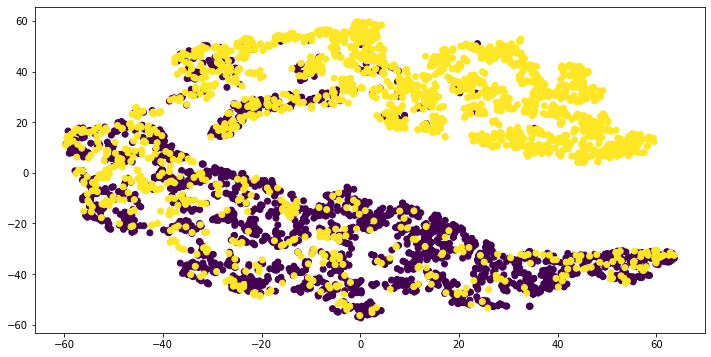

In [8]:
#展示Bc_one效果
#train_datas_T_one,train_labels_T_one = make_new_datas_tsne(train_d_one,Bc_one)
val_datas_T_one,val_labels_T_one = make_new_datas_tsne(val_d_one,Bc_one)

#---------------------------------------------------------------------------------

# print(train_datas_T_one.shape)
# print(train_labels_T_one.shape)
# # 使用TSNE进行降维处理。降至2维。
# tsne =TSNE(n_components=2, learning_rate=100).fit_transform(train_datas_T_one)
 
# print("train_datas_one")
# # 设置画布的大小
# plt.figure(figsize=(12, 6))
# plt.subplot(111)
# plt.scatter(tsne[:, 0], tsne[:, 1], c=train_labels_T_one)
# plt.show()




print(val_datas_T_one.shape)
print(val_labels_T_one.shape)
tsne = TSNE(n_components=2, learning_rate=100).fit_transform(val_datas_T_one)

print("val_datas_one")
# 设置画布的大小
plt.figure(figsize=(12, 6))
plt.subplot(111)
plt.scatter(tsne[:, 0], tsne[:, 1], c=val_labels_T_one)
plt.show()

In [31]:
from xgboost import XGBClassifier
xgb=XGBClassifier(learning_rate=0.001,n_estimators=400,max_depth=8,min_child_weight=0.3,gamma=5,subsample=1,  
                         colsample_bytree=0.9,objective= 'binary:logistic',scale_pos_weight=0.08,seed=120,reg_alpha=0.001)
# knn = KNeighborsClassifier(n_neighbors=2000)    #实例化KNN模型
xgb.fit(t_d_one, t_l_one)      #放入训练数据进行训练
pred=xgb.predict(v_d_one) 
 #获得平均的单个段的识别率
Len=v_l_one.shape[0]
num=0
for i in range(Len):
    if(pred[i]==v_l_one[i]):
        num+=1
Accuracy=num/Len
print("Accuracy:",Accuracy)

[23:25:23] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Accuracy: 0.8101300108342362


In [33]:
import joblib
#xgb=joblib.load('step_one.model')

In [34]:

#lr是一个LogisticRegression模型
joblib.dump(xgb, 'step_one.model')
#lr = joblib.load('lr.model')

['step_one.model']

In [9]:
Data_for_one=get_datas_for_test_NOW('plp','test',Bc_one,All=False,method='audio')

In [10]:
ad=0
n_ad=0
#三类音频
for p in range(3):
    for m in range(len(Data_for_one[p])):#j指类中的数组对
        Audio=Data_for_one[p][m]

        pred=xgb.predict(Audio)#pred为预测的标签
        a=0
        b=0        
        #计算预测的的结果
        #0为ad 1为hc_mci
        for k in pred:
            if(k==0):
                a+=1
            if(k==1):
                b+=1

        res=b/(a+b)   
        if(res<=0.4 and p==0):#认定为AD
            ad+=1
        if(res>0.4 and p!=0):#否则认定为HC_MCI,进而进行第二次分类
            n_ad+=1

#ad准确率
print("ad:",ad/np.array(Data_for_one[0]).shape[0])

#n_ad准确率
print("n_ad:",n_ad/(np.array(Data_for_one[1]).shape[0]+np.array(Data_for_one[2]).shape[0]))

print("average:",(ad/np.array(Data_for_one[0]).shape[0]+n_ad/(np.array(Data_for_one[1]).shape[0]+np.array(Data_for_one[2]).shape[0]))/2)

ad: 0.0
n_ad: 1.0
average: 0.5


C:\Users\dell\AppData\Local\Temp\ipykernel_3092\1194242642.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  print("ad:",ad/np.array(Data_for_one[0]).shape[0])
C:\Users\dell\AppData\Local\Temp\ipykernel_3092\1194242642.py:29: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  print("n_ad:",n_ad/(np.array(Data_for_one[1]).shape[0]+np.array(Data_for_one[2]).shape[0]))
C:\Users\dell\AppData\Local\Temp\ipykernel_3092\1194242642.py:31: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or n

# step_two

In [8]:
#获取用于knn的测试集与验证集

#model_69最高 70.5,整体82
#11
#26和36
Bc_two=tf.keras.models.load_model('save_model/model_two/3')
t_d_two,t_l_two = make_new_datas_knn(train_d_two,Bc_two)
v_d_two,v_l_two = make_new_datas_knn(val_d_two,Bc_two)
    
    
 

In [74]:
from xgboost import XGBClassifier
xgb=XGBClassifier(learning_rate=0.001,n_estimators=500,max_depth=12,min_child_weight=0.01,gamma=0.001,subsample=0.8,  
                         colsample_bytree=0.5,objective= 'binary:logistic',scale_pos_weight=0.3,seed=100,reg_alpha=0.002)
# knn = KNeighborsClassifier(n_neighbors=2000)    #实例化KNN模型
xgb.fit(t_d_two, t_l_two)      #放入训练数据进行训练
pred=xgb.predict(v_d_two) 

 #获得平均的单个段的识别率
Len=v_l_two.shape[0]
num=0
for i in range(Len):
    if(pred[i]==v_l_two[i]):
        num+=1
Accuracy=num/Len
print("Accuracy:",Accuracy)

NameError: name 't_d_two' is not defined

In [72]:
Data_for_two=get_datas_for_test_NOW('test',Bc_two,All=True)

In [77]:
hc=0
mci=0
#三类音频
for p in [1,2]:
    for m in range(len(Data_for_two[p])):#j指类中的数组对
        Audio=Data_for_two[p][m]

        pred=xgb.predict(Audio)#pred为预测的标签
        a=0
        b=0        
        #计算预测的的结果
        #0为hc 1为mci
        for k in pred:
            if(k==0):
                a+=1
            if(k==1):
                b+=1

        res=b/(a+b)   
        if(res<=0.5 and p==1):#认定为hc
            hc+=1
        if(res>0.5 and p!=1):#否则认定为mci,进而进行第二次分类
            mci+=1

#hc准确率
print("hc:",hc/np.array(Data_for_two[1]).shape[0])

#mci准确率
print("mci:",mci/np.array(Data_for_two[2]).shape[0])

print("average:",(hc/np.array(Data_for_two[1]).shape[0]+mci/(np.array(Data_for_two[2]).shape[0]))/2)

hc: 0.8888888888888888
mci: 0.8205128205128205
average: 0.8547008547008547


C:\Users\dell\AppData\Local\Temp\ipykernel_28252\2171390667.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  print("hc:",hc/np.array(Data_for_two[1]).shape[0])
C:\Users\dell\AppData\Local\Temp\ipykernel_28252\2171390667.py:29: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  print("mci:",mci/np.array(Data_for_two[2]).shape[0])
C:\Users\dell\AppData\Local\Temp\ipykernel_28252\2171390667.py:31: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or sh

In [24]:
for i in Data_for_one[0]:
    print(np.array(i).shape)

(19, 128)
(18, 128)
(18, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(16, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(19, 128)
(18, 128)
(19, 128)
(18, 128)
(19, 128)
(19, 128)


In [15]:
a=np.array([2,4,8])
b=np.array([3,3,9])

In [16]:
tf.where(a<b,b,a)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([3, 4, 9])>

In [9]:
a=np.array([2,4,8])
b=np.array([3,3,9])

In [10]:
tf.where(a>b,b,a)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([2, 3, 8])>